# Tugas - Klasifikasi dengan Support Vector Machine (SVM)

| Nama | NRP |
|------|-----|
| Zico Diego Rio Ramadhonny | 5054251023 |

## Deskripsi Tugas
Pada tugas ini, kalian akan membangun model SVM Classifier untuk menyelesaikan sebuah masalah klasifikasi.

Dataset dapat diakses melalui link berikut:
[Link dataset akan diinformasikan terpisah]

Tujuan utama dari tugas ini adalah memahami cara kerja SVM secara praktik, khususnya:
1. Perbedaan hasil antara kernel Linear dan kernel RBF
2. Pengaruh parameter `C` dan `gamma` terhadap gejala overfitting/underfitting

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model, termasuk feature scaling.
3. Eksperimen Model
   - Bangun model SVM dengan kernel Linear dan kernel RBF.
   - Lakukan eksperimen regularisasi dengan variasi nilai `C` dan `gamma`.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil eksperimen dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [4]:
# Import library yang dibutuhkan
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score,
    f1_score, 
    confusion_matrix, 
    classification_report
)

In [5]:
# Load dataset dan tampilkan informasi dasar
path = kagglehub.dataset_download("uciml/breast-cancer-wisconsin-data")
print("Path to dataset files:", path)

dataset_file = None
files_in_path = [os.path.join(path, file) for file in os.listdir(path)]
for file in files_in_path:
    if os.path.isfile(file) and os.path.splitext(os.path.basename(file))[-1] == ".csv":
        dataset_file = file
        break
    
if dataset_file is None:
    raise FileNotFoundError(f"CSV dataset file can't be found at {path}.")

#  Load Dataset dan menampilkan informasi dasar tentang dataset, seperti jumlah baris dan kolom, tipe data, jumlah nilai yang hilang, dan informasi lainnya yang dibutuhkan.
df = pd.read_csv(dataset_file)

print("Jumlah baris dan kolom:", df.shape)
print("\n=== Tipe data ===")
print(df.dtypes.value_counts())
print("\n=== 5 baris pertama ===")
display(df.head())
print("\n=== Statistik deskriptif ===")
display(df.describe().T)
print("\n=== Kolom dengan missing value ===")
missing = df.isnull().sum()
print(missing[missing > 0])

Path to dataset files: /home/zico/.cache/kagglehub/datasets/uciml/breast-cancer-wisconsin-data/versions/2
Jumlah baris dan kolom: (569, 33)

=== Tipe data ===
float64    31
int64       1
str         1
Name: count, dtype: int64

=== 5 baris pertama ===


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN



=== Statistik deskriptif ===


,count,mean,std,min,25%,50%,75%,max
id,569.0,3.037183e+07,1.250206e+08,8670.000000,869218.000000,906024.000000,8.813129e+06,9.113205e+08
radius_mean,569.0,1.412729e+01,3.524049e+00,6.981000,11.700000,13.370000,1.578000e+01,2.811000e+01
texture_mean,569.0,1.928965e+01,4.301036e+00,9.710000,16.170000,18.840000,2.180000e+01,3.928000e+01
perimeter_mean,569.0,9.196903e+01,2.429898e+01,43.790000,75.170000,86.240000,1.041000e+02,1.885000e+02
area_mean,569.0,6.548891e+02,3.519141e+02,143.500000,420.300000,551.100000,7.827000e+02,2.501000e+03
smoothness_mean,569.0,9.636028e-02,1.406413e-02,0.052630,0.086370,0.095870,1.053000e-01,1.634000e-01
compactness_mean,569.0,1.043410e-01,5.281276e-02,0.019380,0.064920,0.092630,1.304000e-01,3.454000e-01
concavity_mean,569.0,8.879932e-02,7.971981e-02,0.000000,0.029560,0.061540,1.307000e-01,4.268000e-01
concave points_mean,569.0,4.891915e-02,3.880284e-02,0.000000,0.020310,0.033500,7.400000e-02,2.012000e-01
symmetry_mean,569.0,1.811619e-01,2.741428e-02,0.106000,0.161900,0.179200,1.957000e-01,3.040000e-01



=== Kolom dengan missing value ===
Unnamed: 32    569
dtype: int64


diagnosis
B    357
M    212
Name: count, dtype: int64

Proporsi (%):
diagnosis
B    62.74
M    37.26
Name: proportion, dtype: float64


/tmp/ipykernel_121293/2951206223.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x="diagnosis", order=["B", "M"], palette=["#4C9F70", "#D1495B"])


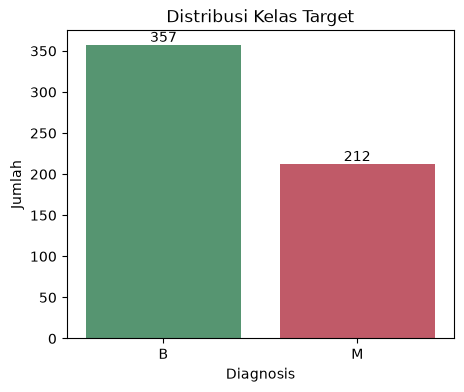

In [6]:
# Distribusi kelas target (diagnosis: B = Benign/jinak, M = Malignant/ganas)
counts = df["diagnosis"].value_counts()
print(counts)
print("\nProporsi (%):")
print((df["diagnosis"].value_counts(normalize=True) * 100).round(2))

plt.figure(figsize=(5, 4))
ax = sns.countplot(data=df, x="diagnosis", order=["B", "M"], palette=["#4C9F70", "#D1495B"])
for p in ax.patches:
    ax.annotate(int(p.get_height()), (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom")
plt.title("Distribusi Kelas Target")
plt.xlabel("Diagnosis")
plt.ylabel("Jumlah")
plt.show()

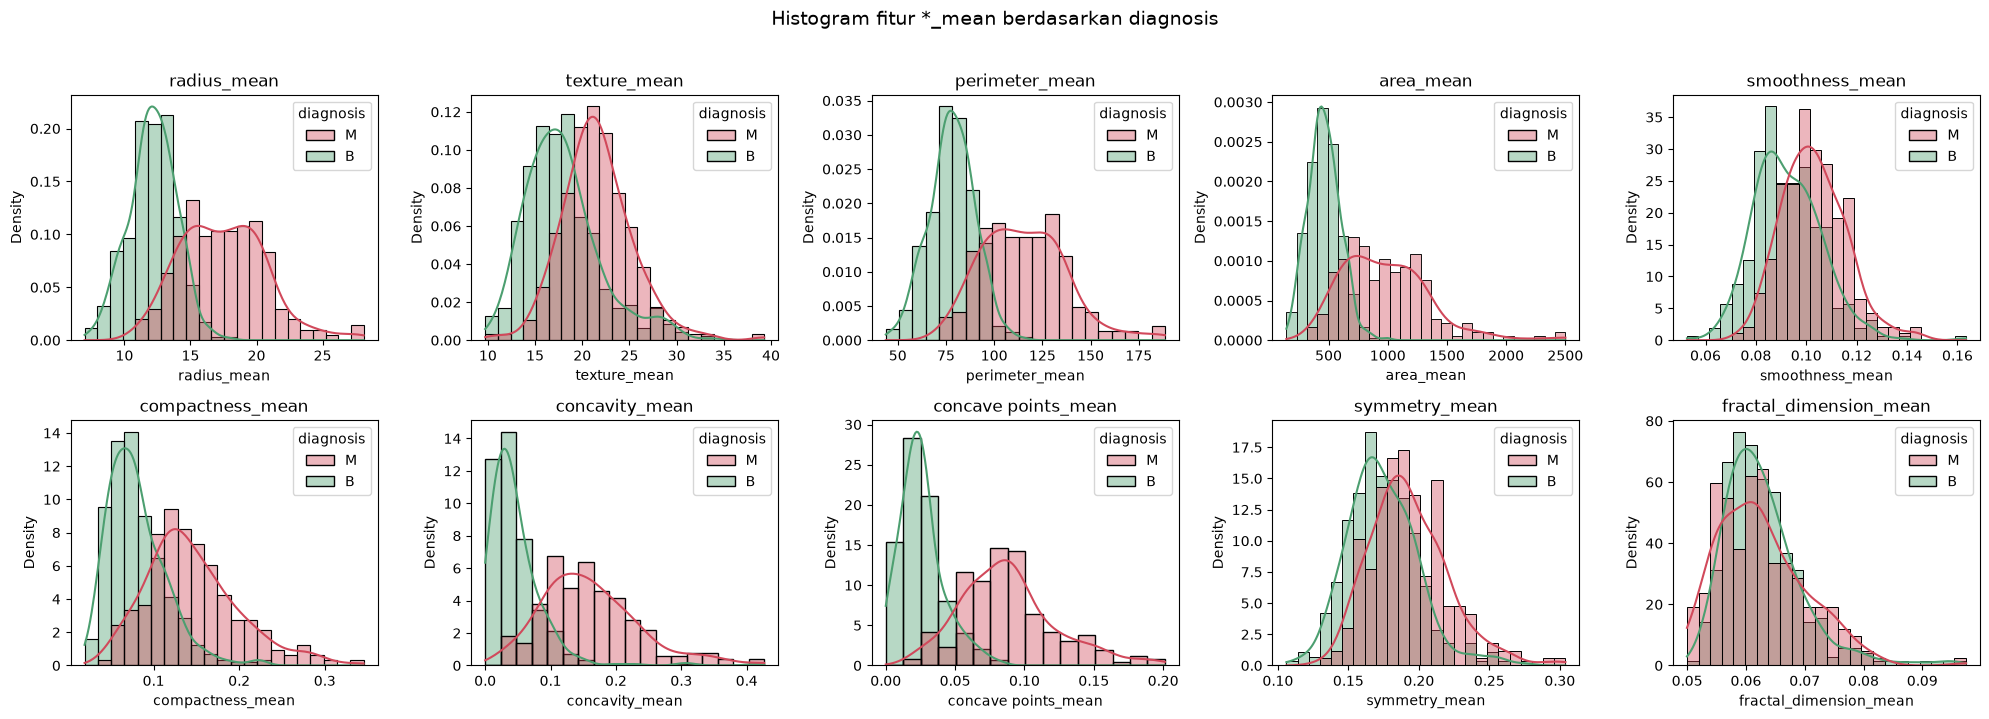

/tmp/ipykernel_121293/2375373793.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="diagnosis", y=col, order=["B", "M"], palette=palette, ax=ax)
/tmp/ipykernel_121293/2375373793.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="diagnosis", y=col, order=["B", "M"], palette=palette, ax=ax)
/tmp/ipykernel_121293/2375373793.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="diagnosis", y=col, order=["B", "M"], palette=palette, ax=ax)
/tmp/ipykernel_121293/2375373793.py:17: FutureWarning: 

Passing `pale

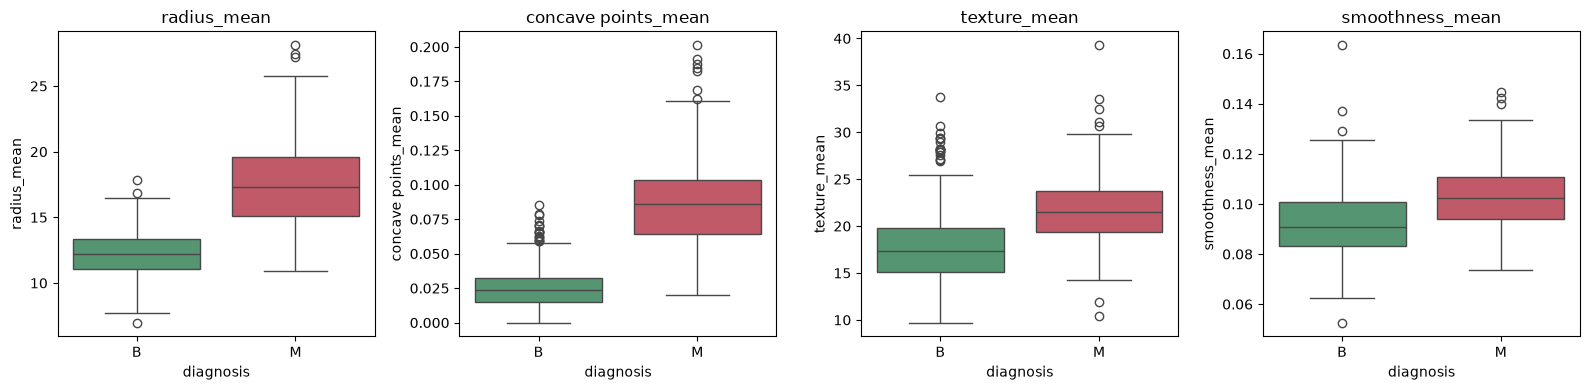

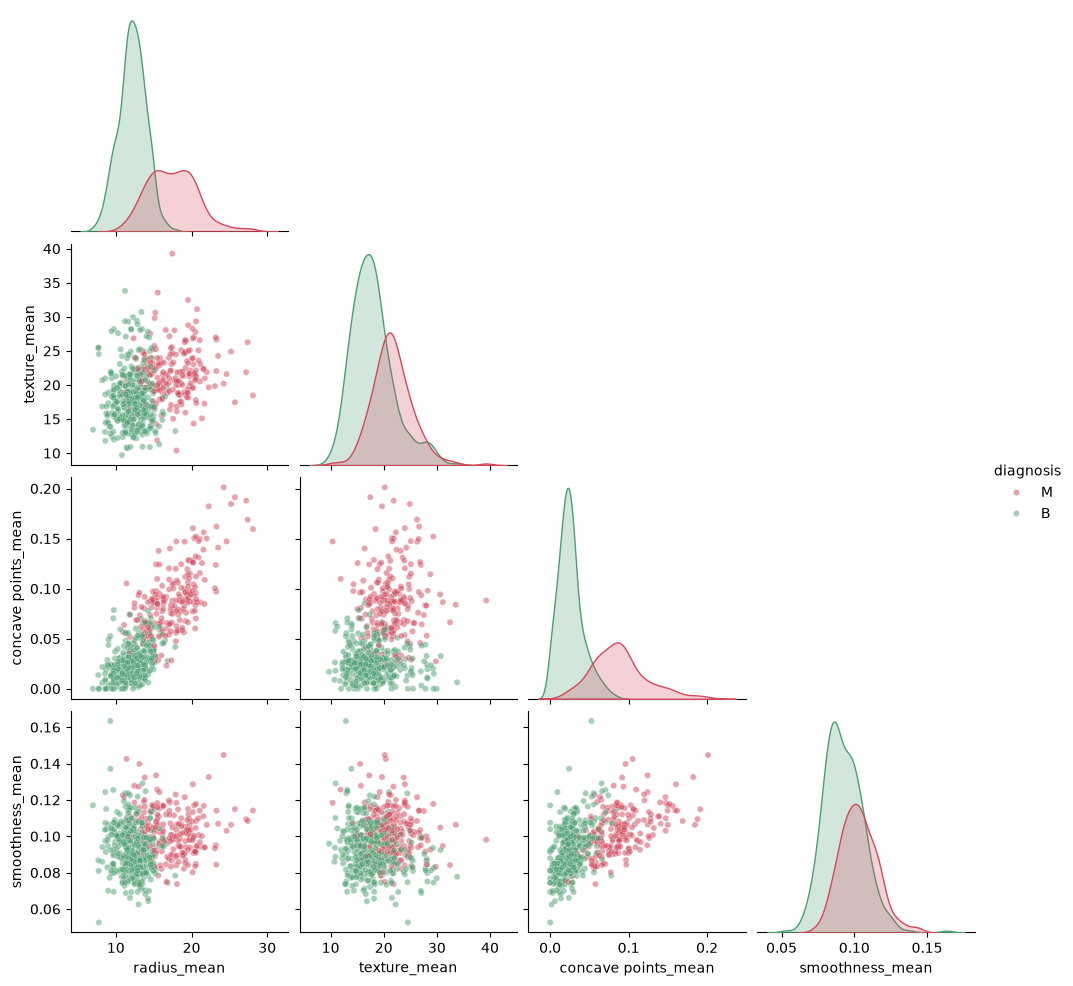

In [7]:
# Distribusi fitur (kelompok *_mean) dibedakan berdasarkan kelas target
mean_features = [c for c in df.columns if c.endswith("_mean")]
palette = {"B": "#4C9F70", "M": "#D1495B"}

fig, axes = plt.subplots(2, 5, figsize=(20, 7))
for ax, col in zip(axes.ravel(), mean_features):
    sns.histplot(data=df, x=col, hue="diagnosis", kde=True, stat="density",
                 common_norm=False, palette=palette, ax=ax, alpha=0.4)
    ax.set_title(col)
plt.suptitle("Histogram fitur *_mean berdasarkan diagnosis", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

# Boxplot fitur yang tampak paling memisahkan kelas
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, ["radius_mean", "concave points_mean", "texture_mean", "smoothness_mean"]):
    sns.boxplot(data=df, x="diagnosis", y=col, order=["B", "M"], palette=palette, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

# Pairplot beberapa fitur utama
sns.pairplot(df, vars=["radius_mean", "texture_mean", "concave points_mean", "smoothness_mean"],
             hue="diagnosis", palette=palette, corner=True, plot_kws={"alpha": 0.5, "s": 20})
plt.show()

## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

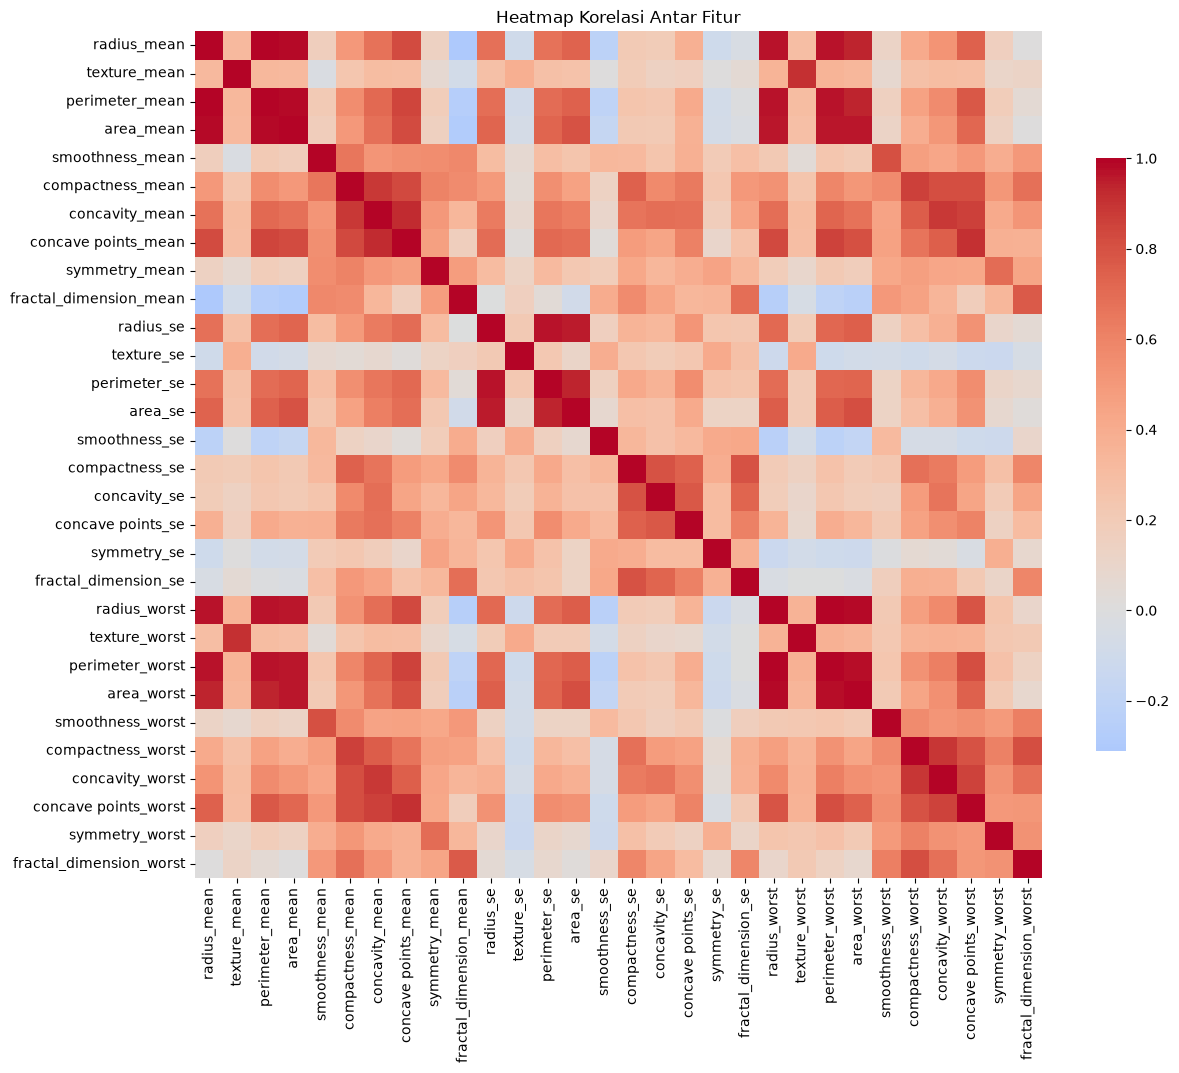

Jumlah pasangan fitur dengan korelasi > 0.9: 21


radius_mean      perimeter_mean     0.998
radius_worst     perimeter_worst    0.994
radius_mean      area_mean          0.987
perimeter_mean   area_mean          0.987
radius_worst     area_worst         0.984
perimeter_worst  area_worst         0.978
radius_se        perimeter_se       0.973
perimeter_mean   perimeter_worst    0.970
dtype: float64

In [8]:
# EDA tambahan 1: korelasi antar fitur (multikolinearitas)
corr = df.drop(columns=["id", "Unnamed: 32", "diagnosis"]).corr()
plt.figure(figsize=(14, 11))
sns.heatmap(corr, cmap="coolwarm", center=0, square=True, cbar_kws={"shrink": 0.7})
plt.title("Heatmap Korelasi Antar Fitur")
plt.show()

# pasangan fitur dengan korelasi sangat tinggi
upper = corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1))
high_corr = upper.stack().sort_values(ascending=False)
print("Jumlah pasangan fitur dengan korelasi > 0.9:", (high_corr > 0.9).sum())
display(high_corr.head(8).round(3))

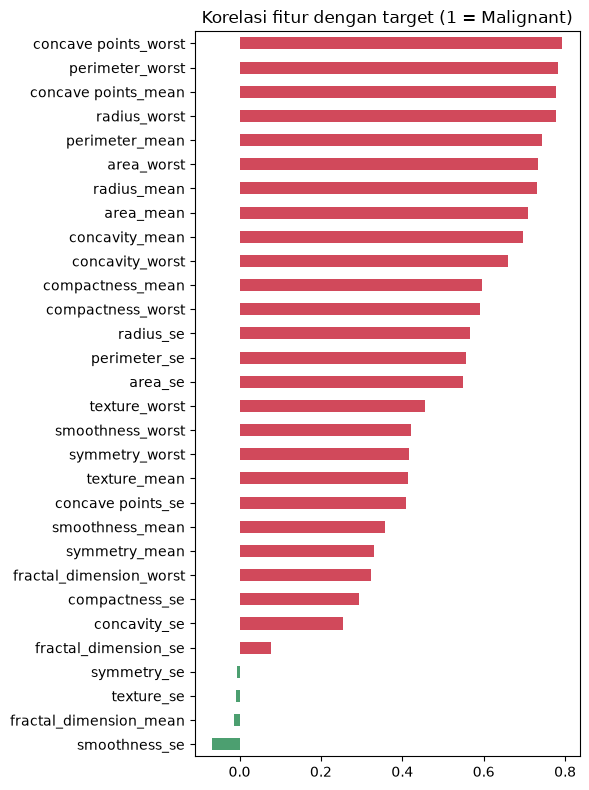

Rentang nilai terbesar vs terkecil antar fitur:


,min,max,range
area_worst,185.200000,4254.00000,4068.800000
area_mean,143.500000,2501.00000,2357.500000
smoothness_se,0.001713,0.03113,0.029417
fractal_dimension_se,0.000895,0.02984,0.028945


In [ ]:
tmp = df.drop(columns=["id", "Unnamed: 32"]).copy()
tmp["diagnosis"] = tmp["diagnosis"].map({"B": 0, "M": 1})

target_corr = tmp.corr()["diagnosis"].drop("diagnosis").sort_values(ascending=False)
plt.figure(figsize=(6, 8))
target_corr.plot(kind="barh", color=np.where(target_corr > 0, "#D1495B", "#4C9F70"))
plt.title("Korelasi fitur dengan target (1 = Malignant)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

rng = tmp.drop(columns="diagnosis").agg(["min", "max"]).T
rng["range"] = rng["max"] - rng["min"]
print("Rentang nilai terbesar vs terkecil antar fitur:")
display(rng.sort_values("range", ascending=False).iloc[[0, 1, -2, -1]])

# 2. Preprocessing

In [ ]:
df_clean = df.drop(columns=["id", "Unnamed: 32"])

print("Shape setelah drop kolom:", df_clean.shape)
print("Total missing value tersisa:", df_clean.isnull().sum().sum())

Shape setelah drop kolom: (569, 31)
Total missing value tersisa: 0


In [ ]:
df_clean["diagnosis"] = df_clean["diagnosis"].map({"B": 0, "M": 1})
print(df_clean["diagnosis"].value_counts())
print("\nTipe data fitur:", df_clean.drop(columns="diagnosis").dtypes.unique())

diagnosis
0    357
1    212
Name: count, dtype: int64

Tipe data fitur: [dtype('float64')]


In [13]:
# Pisahkan fitur (X) dan target (y), lalu split train:test = 80:20 dengan stratify
RANDOM_STATE = 42
X            = df_clean.drop(columns="diagnosis")
y            = df_clean["diagnosis"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("X_train:", X_train.shape, "| X_test:", X_test.shape)
print("\nProporsi kelas ganas (M):")
print(f"  Train: {y_train.mean():.3f} | Test: {y_test.mean():.3f} | Total: {y.mean():.3f}")

X_train: (455, 30) | X_test: (114, 30)

Proporsi kelas ganas (M):
  Train: 0.374 | Test: 0.368 | Total: 0.373


**Catatan penting:** SVM adalah algoritma berbasis jarak (margin dihitung dari posisi antar titik data), sehingga sangat sensitif terhadap skala fitur. Fitur dengan rentang nilai besar bisa mendominasi perhitungan jarak meskipun sebenarnya tidak lebih penting. Lakukan **feature scaling** (misalnya `StandardScaler`) pada fitur numerik sebelum training. Ingat: `fit` scaler hanya pada train set, lalu `transform` ke train dan test set, agar tidak terjadi data leakage.

In [14]:
# Feature scaling dengan StandardScaler
# fit hanya pada train set, transform pada train dan test (mencegah data leakage)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Eksperimen Model

## 3.1 SVM dengan Kernel Linear

Kernel Linear mencari hyperplane pemisah berupa garis/bidang lurus, tanpa proyeksi ke dimensi yang lebih tinggi. Cocok digunakan sebagai baseline, terutama jika dari hasil EDA data terlihat cukup terpisah secara linear.

In [ ]:
C_BASE = 1.0

svm_linear = SVC(kernel="linear", C=C_BASE, random_state=RANDOM_STATE)
svm_linear.fit(X_train_scaled, y_train)

print("SVM Linear berhasil dilatih.")
print(f"Akurasi train: {svm_linear.score(X_train_scaled, y_train):.4f}")

SVM Linear berhasil dilatih.
Akurasi train: 0.9890


In [17]:
# Prediksi pada test set (kernel linear)
y_pred_linear = svm_linear.predict(X_test_scaled)
print(f"Akurasi test (Linear): {accuracy_score(y_test, y_pred_linear):.4f}")

Akurasi test (Linear): 0.9649


## 3.2 SVM dengan Kernel RBF

Kernel RBF (Radial Basis Function) memproyeksikan data ke ruang berdimensi lebih tinggi melalui kernel trick, sehingga mampu menangani batas keputusan yang non-linear.

In [18]:
svm_rbf = SVC(kernel="rbf", C=C_BASE, gamma="scale", random_state=RANDOM_STATE)
svm_rbf.fit(X_train_scaled, y_train)

print("SVM RBF berhasil dilatih.")
print(f"Akurasi train: {svm_rbf.score(X_train_scaled, y_train):.4f}")

SVM RBF berhasil dilatih.
Akurasi train: 0.9868


In [ ]:
# Prediksi pada test set (kernel RBF)
y_pred_rbf = svm_rbf.predict(X_test_scaled)
print(f"Akurasi test (RBF): {accuracy_score(y_test, y_pred_rbf):.4f}")

Akurasi test (RBF): 0.9737


## 3.3 Eksperimen Regularisasi: Pengaruh C dan Gamma terhadap Overfitting

Parameter `C` mengatur trade-off antara margin lebar dan toleransi kesalahan klasifikasi, sedangkan `gamma` (khusus kernel RBF) mengatur seberapa lokal pengaruh tiap titik data. Pada bagian ini kalian akan mengamati bagaimana perubahan nilai `C` (dan/atau `gamma`) memengaruhi akurasi training dan testing.

In [33]:
# Latih beberapa model SVC (RBF) dengan variasi nilai C, gamma='scale' tetap
C_values = [i/100 for i in range(1, 10000 + 1)]
models_C = {}

for C in C_values:
    m = SVC(kernel="rbf", C=C, gamma="scale", random_state=RANDOM_STATE)
    m.fit(X_train_scaled, y_train)
    models_C[C] = m

print("Model terlatih untuk C =", list(models_C.keys()))

Model terlatih untuk C = [0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1, 0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2, 0.21, 0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3, 0.31, 0.32, 0.33, 0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.4, 0.41, 0.42, 0.43, 0.44, 0.45, 0.46, 0.47, 0.48, 0.49, 0.5, 0.51, 0.52, 0.53, 0.54, 0.55, 0.56, 0.57, 0.58, 0.59, 0.6, 0.61, 0.62, 0.63, 0.64, 0.65, 0.66, 0.67, 0.68, 0.69, 0.7, 0.71, 0.72, 0.73, 0.74, 0.75, 0.76, 0.77, 0.78, 0.79, 0.8, 0.81, 0.82, 0.83, 0.84, 0.85, 0.86, 0.87, 0.88, 0.89, 0.9, 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99, 1.0, 1.01, 1.02, 1.03, 1.04, 1.05, 1.06, 1.07, 1.08, 1.09, 1.1, 1.11, 1.12, 1.13, 1.14, 1.15, 1.16, 1.17, 1.18, 1.19, 1.2, 1.21, 1.22, 1.23, 1.24, 1.25, 1.26, 1.27, 1.28, 1.29, 1.3, 1.31, 1.32, 1.33, 1.34, 1.35, 1.36, 1.37, 1.38, 1.39, 1.4, 1.41, 1.42, 1.43, 1.44, 1.45, 1.46, 1.47, 1.48, 1.49, 1.5, 1.51, 1.52, 1.53, 1.54, 1.55, 1.56, 1.57, 1.58, 1.59, 1.6, 1.61, 1.62, 1.63, 1.64, 1.65, 

In [43]:
# Hitung akurasi train dan test untuk setiap nilai C
results_C = []
for C, m in models_C.items():
    results_C.append({
        "C": C,
        "train_acc": m.score(X_train_scaled, y_train),
        "test_acc": m.score(X_test_scaled, y_test),
        "n_support_vectors": int(m.n_support_.sum()),
    })

results_C = pd.DataFrame(results_C)
results_C["gap (train - test)"] = results_C["train_acc"] - results_C["test_acc"]
display(results_C.round(4))

test_acc_max        = max(results_C["test_acc"])
c_with_max_test_acc = results_C.loc[results_C["test_acc"] == test_acc_max]

least_gap             = min(c_with_max_test_acc["gap (train - test)"])
best_c_with_least_gap = c_with_max_test_acc.loc[c_with_max_test_acc["gap (train - test)"] == least_gap]

least_support_vector  = min(best_c_with_least_gap["n_support_vectors"])
best_c_with_least_gap_and_least_vector = best_c_with_least_gap.loc[best_c_with_least_gap["n_support_vectors"] == least_support_vector]

print("Best C value (based on support vector count, test accuracy, and gap between training and testing):")
display(best_c_with_least_gap_and_least_vector)
print("C:", best_c_with_least_gap_and_least_vector["C"].unique().tolist())

,C,train_acc,test_acc,n_support_vectors,gap (train - test)
0,0.01,0.6264,0.6316,341,-0.0052
1,0.02,0.9121,0.9035,341,0.0086
2,0.03,0.9473,0.9474,307,-0.0001
3,0.04,0.9429,0.9386,280,0.0043
4,0.05,0.9429,0.9298,256,0.0130
...,...,...,...,...,...
9995,99.96,1.0000,0.9649,70,0.0351
9996,99.97,1.0000,0.9649,70,0.0351
9997,99.98,1.0000,0.9649,70,0.0351
9998,99.99,1.0000,0.9649,70,0.0351


Best C value (based on support vector count, test accuracy, and gap between training and testing):


,C,train_acc,test_acc,n_support_vectors,gap (train - test)
161,1.62,0.986813,0.982456,92,0.004357
162,1.63,0.986813,0.982456,92,0.004357
163,1.64,0.986813,0.982456,92,0.004357
164,1.65,0.986813,0.982456,92,0.004357
165,1.66,0.986813,0.982456,92,0.004357
...,...,...,...,...,...
238,2.39,0.986813,0.982456,92,0.004357
239,2.40,0.986813,0.982456,92,0.004357
240,2.41,0.986813,0.982456,92,0.004357
241,2.42,0.986813,0.982456,92,0.004357


C: [1.62, 1.63, 1.64, 1.65, 1.66, 1.67, 1.68, 1.69, 1.7, 1.71, 1.72, 1.73, 1.74, 1.75, 1.76, 1.77, 1.78, 1.79, 1.8, 1.81, 1.82, 1.83, 1.84, 1.85, 1.86, 1.87, 1.88, 1.89, 1.9, 1.91, 2.0, 2.01, 2.02, 2.03, 2.04, 2.05, 2.06, 2.07, 2.08, 2.09, 2.1, 2.11, 2.12, 2.14, 2.15, 2.16, 2.17, 2.18, 2.19, 2.2, 2.21, 2.22, 2.23, 2.24, 2.25, 2.26, 2.27, 2.28, 2.29, 2.3, 2.31, 2.32, 2.33, 2.34, 2.35, 2.36, 2.37, 2.38, 2.39, 2.4, 2.41, 2.42, 2.43]


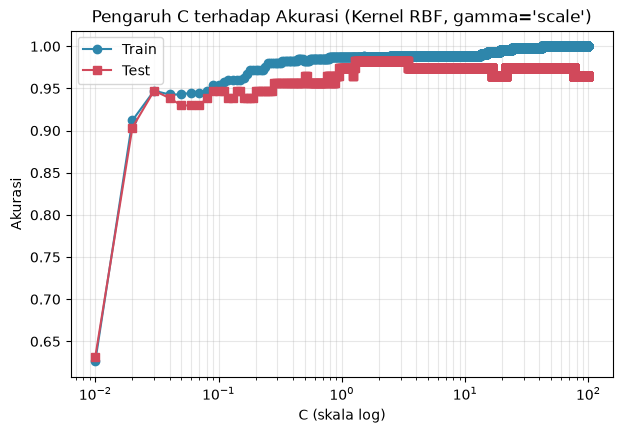

In [38]:
# Plot akurasi training vs testing terhadap C (sumbu x logaritmik)
plt.figure(figsize=(7, 4.5))
plt.plot(results_C["C"], results_C["train_acc"], "o-", label="Train", color="#2E86AB")
plt.plot(results_C["C"], results_C["test_acc"], "s-", label="Test", color="#D1495B")
plt.xscale("log")
plt.xlabel("C (skala log)")
plt.ylabel("Akurasi")
plt.title("Pengaruh C terhadap Akurasi (Kernel RBF, gamma='scale')")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

# 4. Evaluasi Model

In [39]:
# Metrik evaluasi: kelas positif = Malignant (1)
def eval_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-Score": f1_score(y_true, y_pred),
    }

metrics_df = pd.DataFrame({
    "Linear": eval_metrics(y_test, y_pred_linear),
    "RBF": eval_metrics(y_test, y_pred_rbf),
}).T
display(metrics_df.round(4))

print("\n=== Classification report: Linear ===")
print(classification_report(y_test, y_pred_linear, target_names=["Benign", "Malignant"]))
print("=== Classification report: RBF ===")
print(classification_report(y_test, y_pred_rbf, target_names=["Benign", "Malignant"]))

,Accuracy,Precision,Recall,F1-Score
Linear,0.9649,1.0,0.9048,0.950
RBF,0.9737,1.0,0.9286,0.963



=== Classification report: Linear ===
              precision    recall  f1-score   support

      Benign       0.95      1.00      0.97        72
   Malignant       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114

=== Classification report: RBF ===
              precision    recall  f1-score   support

      Benign       0.96      1.00      0.98        72
   Malignant       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



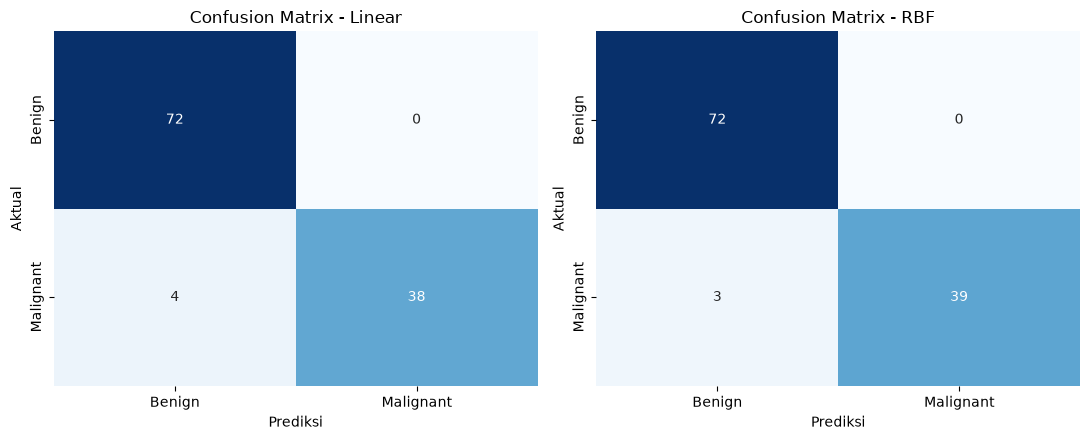

In [40]:
# Confusion matrix (heatmap) untuk Linear dan RBF dalam satu baris
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (name, pred) in zip(axes, [("Linear", y_pred_linear), ("RBF", y_pred_rbf)]):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["Benign", "Malignant"], yticklabels=["Benign", "Malignant"])
    ax.set_title(f"Confusion Matrix - {name}")
    ax.set_xlabel("Prediksi")
    ax.set_ylabel("Aktual")
plt.tight_layout()
plt.show()

In [41]:
# Jumlah support vectors: Linear vs RBF
sv_table = pd.DataFrame({
    "Benign (0)": [svm_linear.n_support_[0], svm_rbf.n_support_[0]],
    "Malignant (1)": [svm_linear.n_support_[1], svm_rbf.n_support_[1]],
    "Total": [svm_linear.support_vectors_.shape[0], svm_rbf.support_vectors_.shape[0]],
}, index=["Linear", "RBF"])
sv_table["% dari data train"] = (sv_table["Total"] / len(X_train_scaled) * 100).round(1)
display(sv_table)

# Model terbaik berdasarkan F1-Score pada test set
best_name = metrics_df["F1-Score"].idxmax()
best_model = svm_linear if best_name == "Linear" else svm_rbf
print(f"Model terbaik berdasarkan F1-Score: {best_name}")

,Benign (0),Malignant (1),Total,% dari data train
Linear,19,19,38,8.4
RBF,50,57,107,23.5


Model terbaik berdasarkan F1-Score: RBF


Explained variance 2 komponen: [0.446 0.185] | total: 0.631
Akurasi model 2D -> train: 0.9407, test: 0.9298


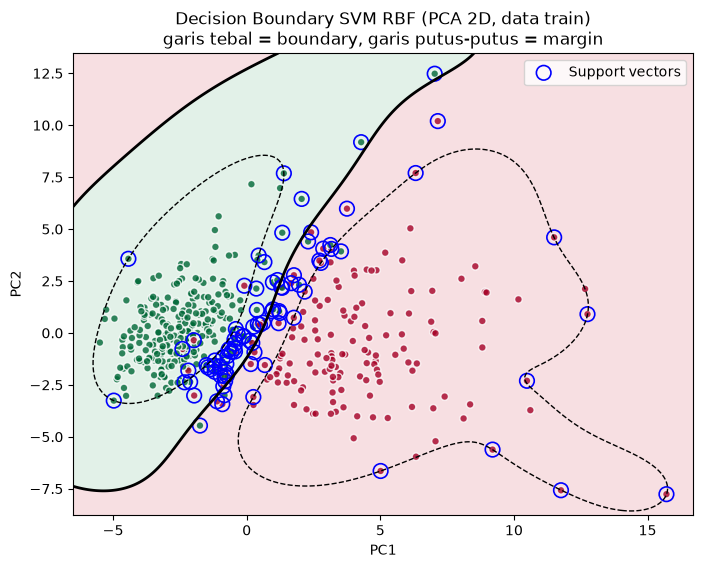

In [26]:
# Visualisasi decision boundary pada ruang 2D hasil PCA
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_train_2d = pca.fit_transform(X_train_scaled)
X_test_2d = pca.transform(X_test_scaled)
print("Explained variance 2 komponen:", pca.explained_variance_ratio_.round(3),
      "| total:", pca.explained_variance_ratio_.sum().round(3))

params = best_model.get_params()
svm_2d = SVC(kernel=params["kernel"], C=params["C"], gamma=params["gamma"],
             random_state=RANDOM_STATE).fit(X_train_2d, y_train)
print(f"Akurasi model 2D -> train: {svm_2d.score(X_train_2d, y_train):.4f}, "
      f"test: {svm_2d.score(X_test_2d, y_test):.4f}")

# Grid untuk decision function
pad = 1
xx, yy = np.meshgrid(
    np.linspace(X_train_2d[:, 0].min() - pad, X_train_2d[:, 0].max() + pad, 400),
    np.linspace(X_train_2d[:, 1].min() - pad, X_train_2d[:, 1].max() + pad, 400),
)
Z = svm_2d.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, levels=[Z.min(), 0, Z.max()], colors=["#CFE8D9", "#F3CBD0"], alpha=0.6)
plt.contour(xx, yy, Z, levels=[-1, 0, 1], colors="k",
            linestyles=["--", "-", "--"], linewidths=[1, 2, 1])
plt.scatter(X_train_2d[:, 0], X_train_2d[:, 1], c=y_train, cmap="RdYlGn_r",
            edgecolor="white", s=30, alpha=0.8)
plt.scatter(svm_2d.support_vectors_[:, 0], svm_2d.support_vectors_[:, 1],
            s=110, facecolors="none", edgecolors="blue", linewidths=1.2, label="Support vectors")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"Decision Boundary SVM {best_name} (PCA 2D, data train)\n"
          "garis tebal = boundary, garis putus-putus = margin")
plt.legend()
plt.show()

# 5. Analisis

### Jelaskan secara detail hasil analisis yang didapatkan dari eksperimen yang telah dilakukan.

Pada hasil eksperimen dengan konfigurasi seed, C, ddan gamma yang sama, kernel RBF menghasilkan skor semua metrik yang lebih besar daripada kernel linear (0.9737 vs 0.9649) dengan selisih yang tipis (kernel RBF hanya benar satu prediksi pada kelas "Malignant"). Ketika dikaitkan dengan dataset, kernel RBF memiliki hyperplane yang lebih bagus dibandingkan dengan kernel linear karena menggunakan dimensi tinggi untuk memisahkan kedua kelas.

Model mencapai puncak pada C di antara rentang [1.62, 2.43] walaupun terdapat nilai C pada rentang tersebut yang memiliki penurunan performa. Setelah C sama dengan 2.43, model mengalami penurunan performa pada data test dan peningkatan performa pada data training, menunjukkan gejala overfitting.

Kernel linear memiliki support vector yang lebih sedikit dibandingkan dengan kernel RBF. Jumlah support vector yang rendah dapat meningkatkan waktu komputasi saat melakukan prediksi, tetapi membuat batas keputusan menjadi lebih sempit untuk data berdimensi tinggi dan/atau data kompleks. Jumlah support vector yang tinggi membuat garis keputusan menjadi lebih jelas dan representatif terhadap keadaan data yang sesungguhnya, tetapi meningkatkan kompleksitas waktu saat melakukan prediksi.

# 6. Kesimpulan dan Saran

### Berikan kesimpulan dari eksperimen yang telah dilakukan.

Kesimpulan: Model sangat bagus untuk data berdimensi tinggi, tetapi sensitif terhadap kernel dan C.

Saran: Gamma